# 可解释性分析 — 论文图表复现

本 Notebook **阶段 B**：从 `intermediate_data/` 里的 `.npz` / `.json` 重绘 **SVG**（`figures/`）。

**阶段 A（生成与论文一致的 PNG / 汇总 JSON）**：在 `interpretability` 源码树里跑 Python 脚本（不在 EVA 仓库内，需单独挂载或 clone `rna_benchmark`）。

## 环境变量（二选一）

```bash
export RNA_BENCHMARK_ROOT=/path/to/rna_benchmark
export INTERPRETABILITY_ROOT=/path/to/rna_benchmark/interpretability
export ARIAL_FONT_PATH=/path/to/arial.ttf   # 可选
```

默认根目录见 `reproduce_paths.py` 中 `interpretability_root()`（可按机器修改）。

## 论文 PNG 与上游脚本（相对 interpretability 根）

| # | 输出 PNG | 上游脚本 |
|---|----------|----------|
| 1 | `DSSR_final_model/circRNA_design/circRNA_RABV_G_circular.png` | `plot_circRNA_RABV_G.py` |
| 2 | `DSSR_final_model/circRNA_design/circRNA_SARS_SP_RBD_combined.png` | `plot_circRNA_SARS_SP_RBD_combined.py` |
| 3 | `.../combined_genome_browser_view.png` | `analyze_mRNA_penalty.py` → `plot_combined_genome_browser.py` |
| 4 | `zeroshot_essentiality/output_8192/figure_bacteria_full_comparison.png` | `plot_bacteria_full_comparison.py`（6 行：Baseline + Evo2 1B/7B/40B + EVA×2） |
| 5 | `zeroshot_essentiality/eukaryote/output_8192/figure_eukaryote_gc_baseline.png` | `plot_eukaryote_gc_baseline.py` |
| 6–9 | `SAE_layer13_like_Evo2_*` density / mean PNG | 各子目录 `plot_*.py` |
| 10 | `UMAP_analysis/umap_euk_vs_prok.png` | `umap_sae_analysis.py` 或 `replot_umap.py` |
| 11–12 | `expert_analysis/expert_activation_*.png` | `analyze_expert_activation.py` |

**SAE 训练**：checkpoint 单独发布；训练循环未纳入本仓库（见 `reproduce_paths` 文档）。

首个代码格会打印完整脚本清单与解析到的路径。


In [ ]:
"""
可解释性分析 - 图表复现（阶段 B：intermediate_data → figures）
"""
import os

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap

try:
    import reproduce_paths as RP
except ModuleNotFoundError:
    from notebooks.interpretability_analysis import reproduce_paths as RP

PROJECT_ROOT = str(RP.project_root())
INTERPRETABILITY_ROOT = str(RP.interpretability_root())
RNA_BENCHMARK_ROOT = str(RP.rna_benchmark_root())
INTERMEDIATE_DIR = str(RP.intermediate_dir())
OUTPUT_DIR = str(RP.figures_dir())
os.makedirs(OUTPUT_DIR, exist_ok=True)

if RP.try_register_arial():
    plt.rcParams["font.family"] = "Arial"
else:
    plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

print("PROJECT_ROOT:         ", PROJECT_ROOT)
print("INTERPRETABILITY_ROOT:", INTERPRETABILITY_ROOT)
print("RNA_BENCHMARK_ROOT:   ", RNA_BENCHMARK_ROOT)
print("INTERMEDIATE_DIR:     ", INTERMEDIATE_DIR)
print("OUTPUT_DIR:           ", OUTPUT_DIR)
RP.print_pipeline_summary()


## 1. 专家路由分析 (Expert Routing Analysis)

检查文件: intermediate_data/expert_routing_no_lineage.npz
文件存在: True
RNA类型: [np.str_('circRNA'), np.str_('lncRNA'), np.str_('mRNA'), np.str_('miRNA'), np.str_('rRNA'), np.str_('snRNA'), np.str_('snoRNA'), np.str_('tRNA')]
层数: 16, 专家数: 8
数据形状: (8, 16, 8)


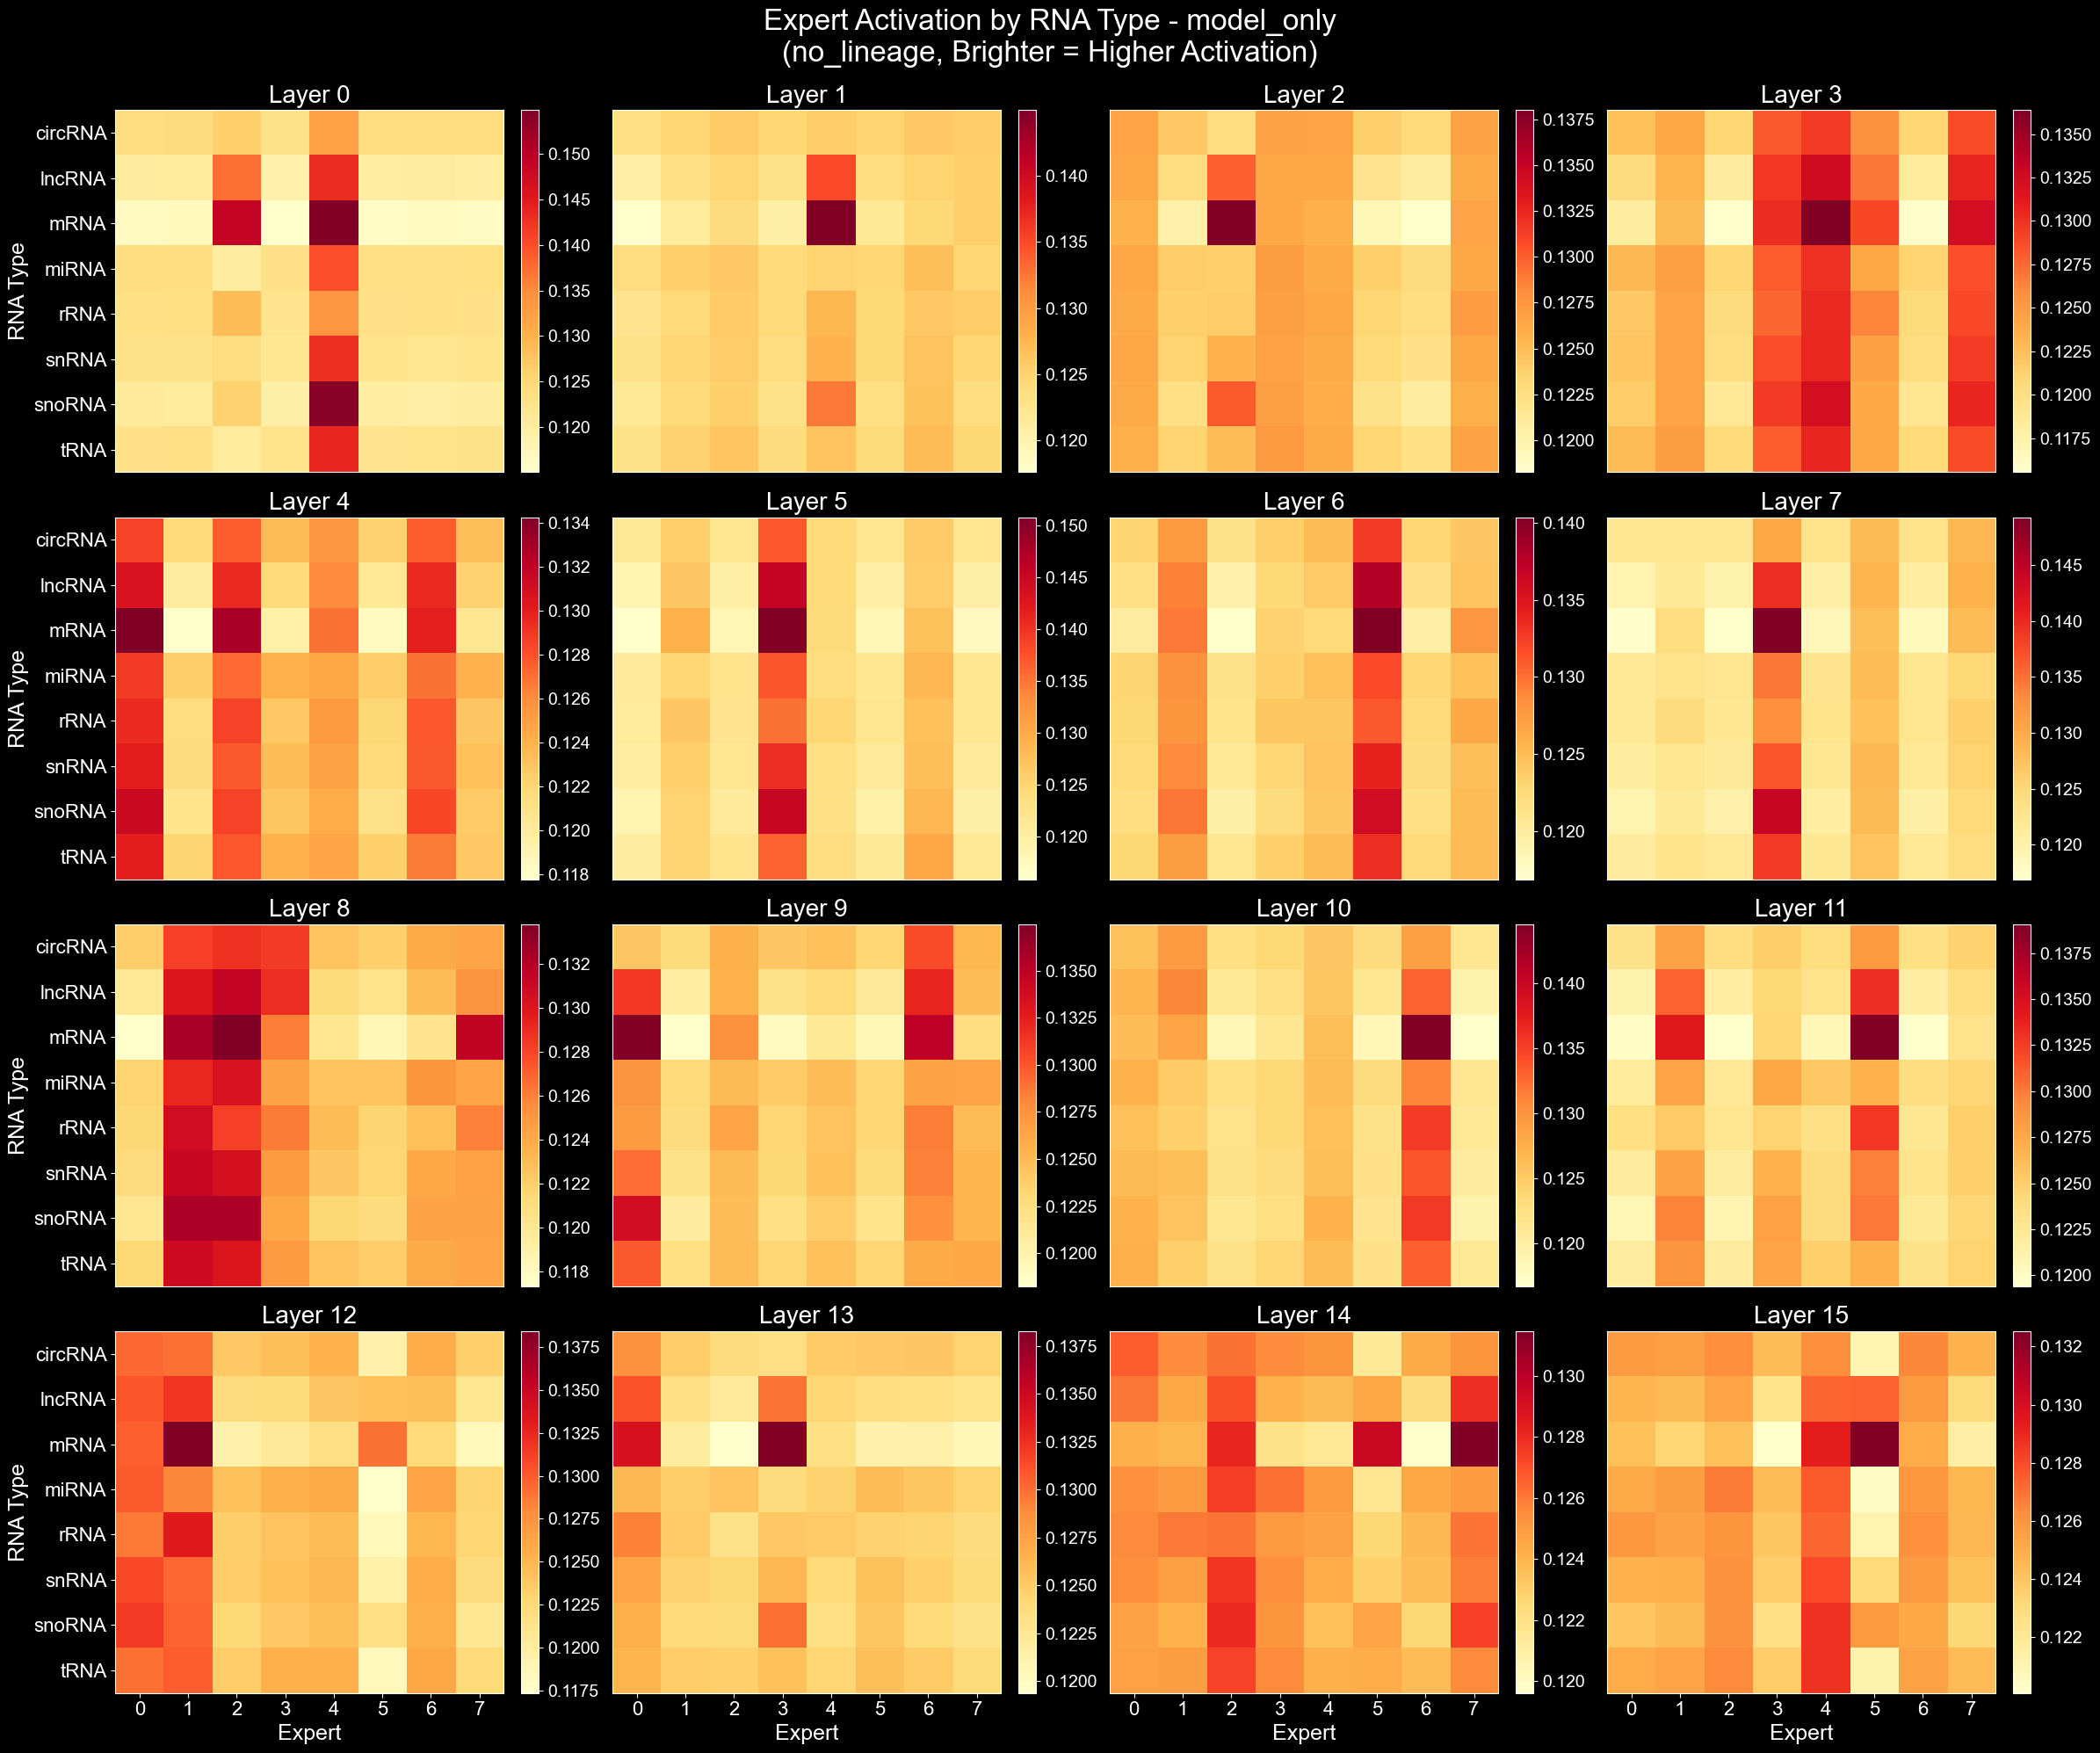

✓ 专家激活模式(无lineage)热力图已保存


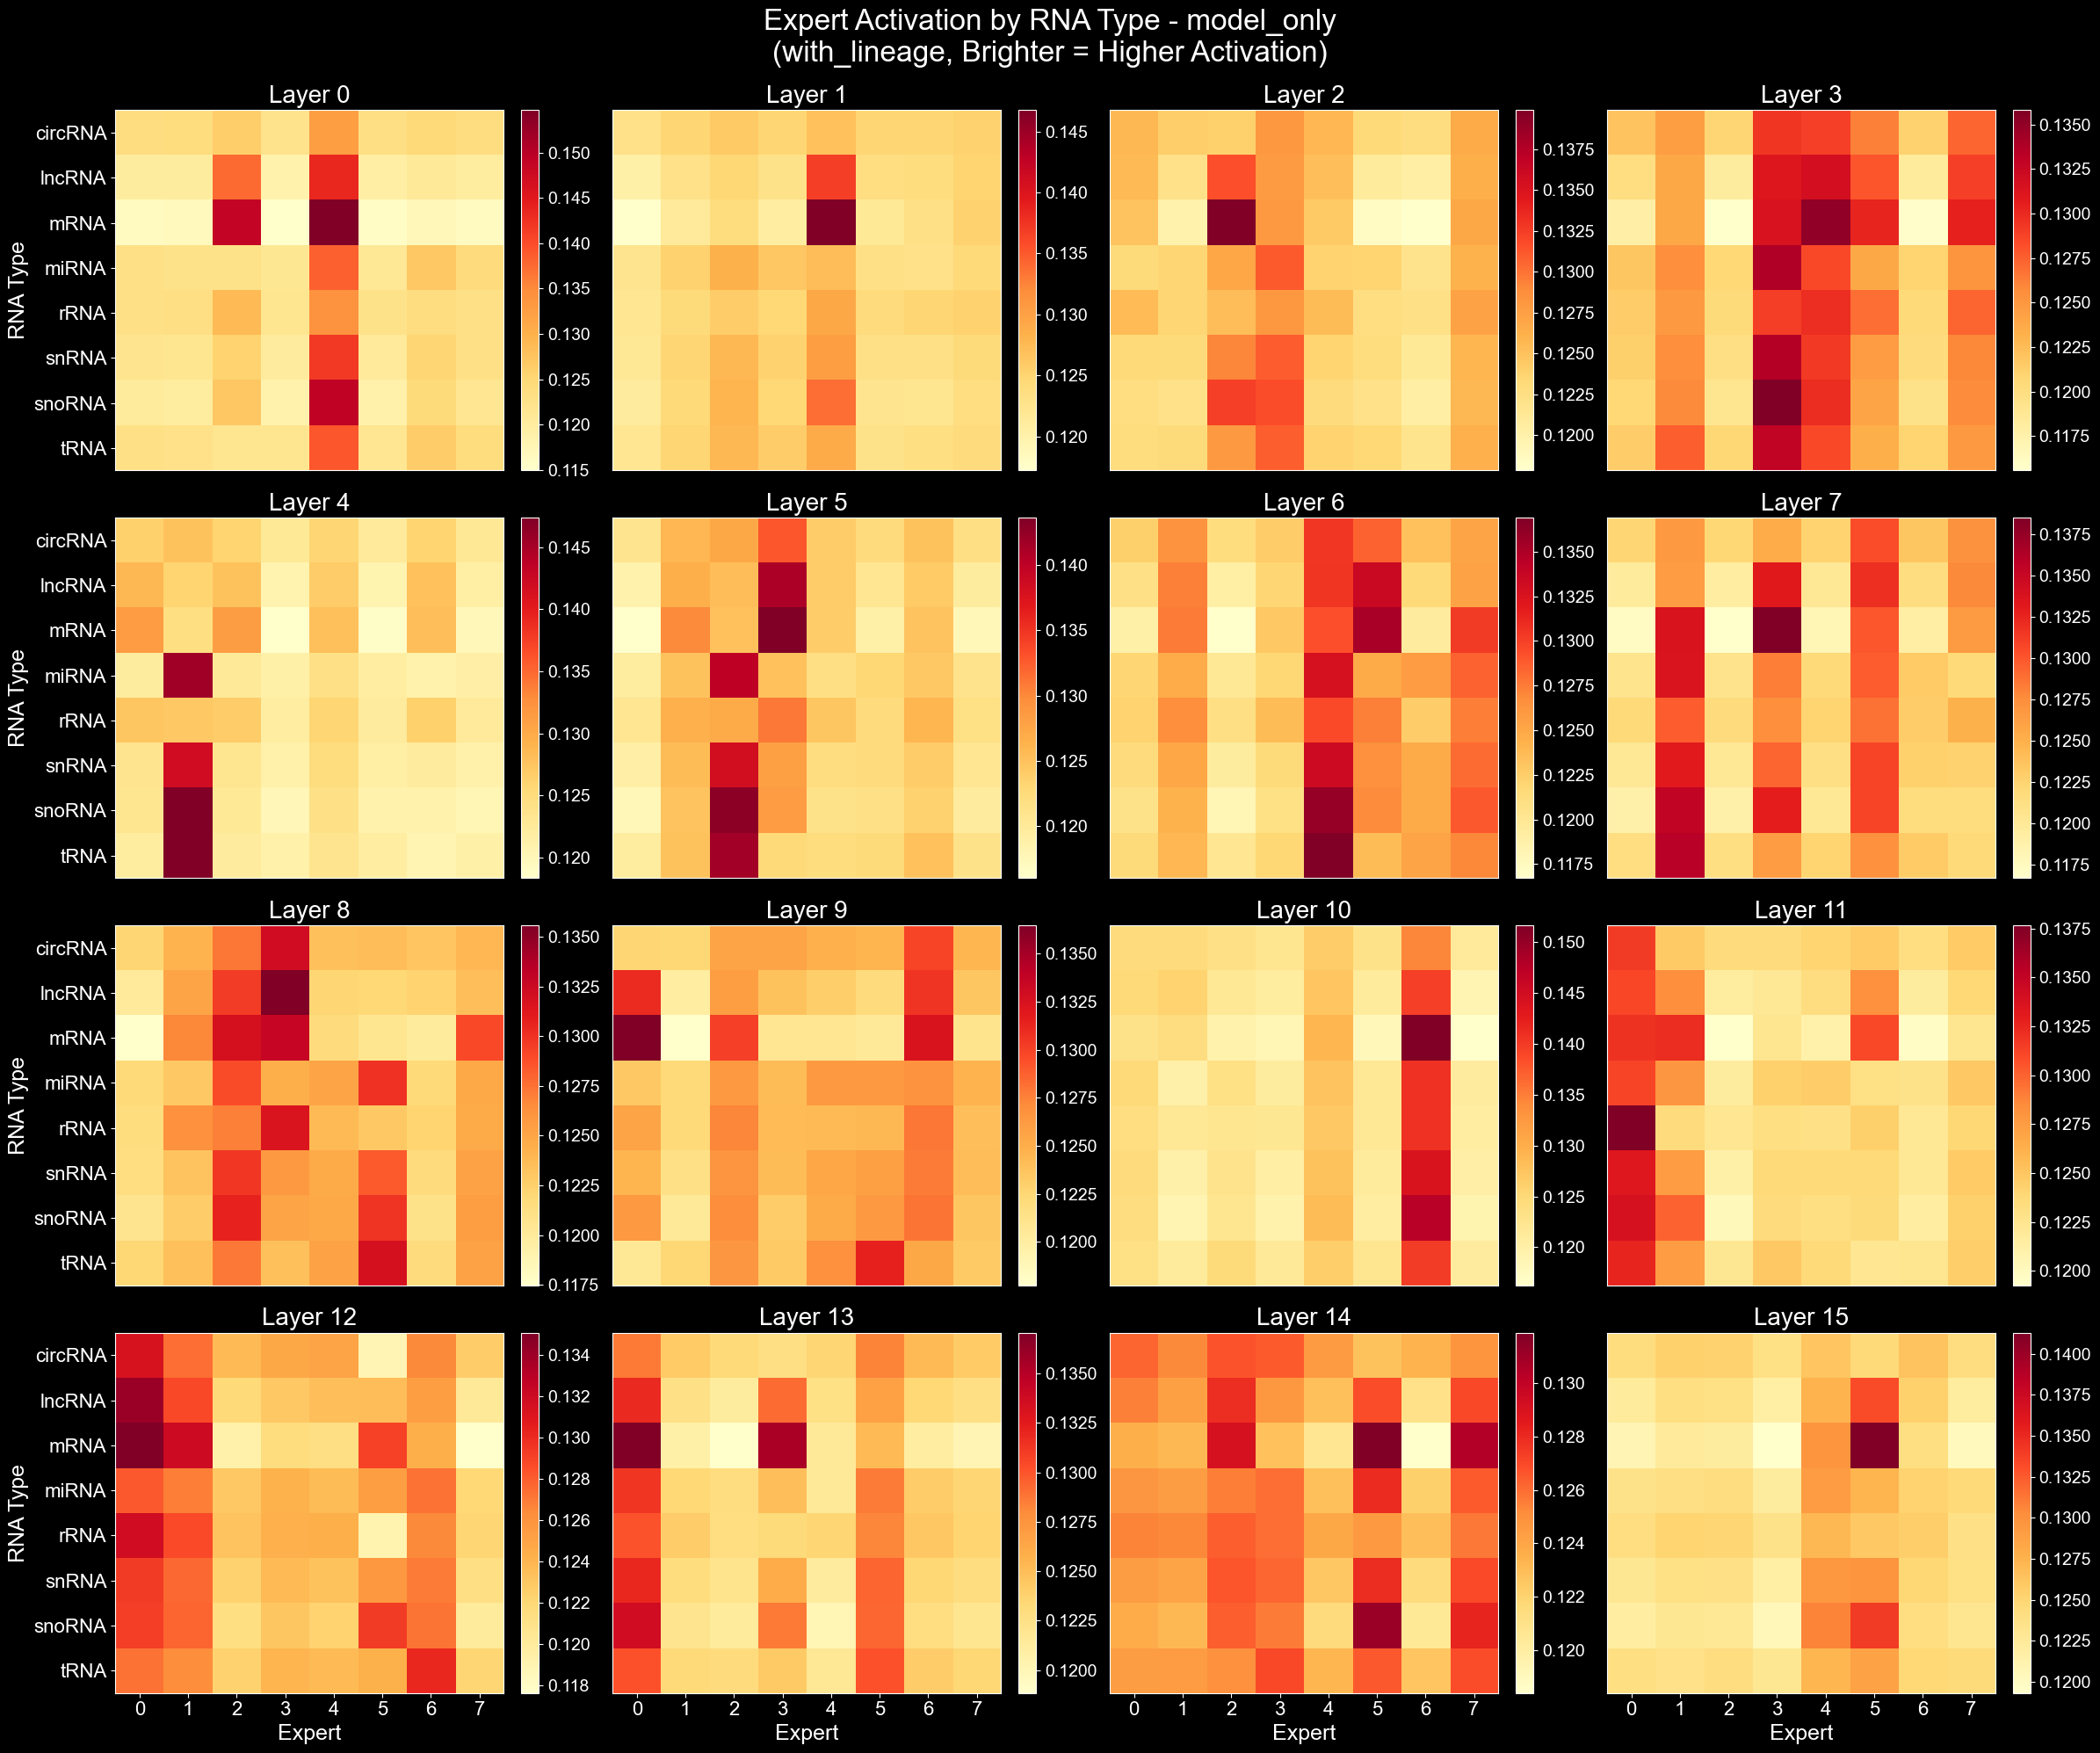

✓ 专家激活模式(有lineage)热力图已保存


In [4]:
# 1. 专家路由分析
expert_no_lineage_file = os.path.join(INTERMEDIATE_DIR, 'expert_routing_no_lineage.npz')
expert_with_lineage_file = os.path.join(INTERMEDIATE_DIR, 'expert_routing_with_lineage.npz')

print(f"检查文件: {expert_no_lineage_file}")
print(f"文件存在: {os.path.exists(expert_no_lineage_file)}")

if os.path.exists(expert_no_lineage_file) and os.path.exists(expert_with_lineage_file):
    data_no_lineage = np.load(expert_no_lineage_file, allow_pickle=True)
    data_with_lineage = np.load(expert_with_lineage_file, allow_pickle=True)
    
    data_no = data_no_lineage['data']
    data_with = data_with_lineage['data']
    rna_types = list(data_no_lineage['rna_types'])
    n_layers = int(data_no_lineage['n_layers'])
    n_experts = int(data_no_lineage['n_experts'])
    
    rna_type_names = list(rna_types)
    print(f"RNA类型: {rna_type_names}")
    print(f"层数: {n_layers}, 专家数: {n_experts}")
    print(f"数据形状: {data_no.shape}")

    fig, axes = plt.subplots(4, 4, figsize=(24, 20))
    axes = axes.flatten()
    
    for layer_idx in range(n_layers):
        ax = axes[layer_idx]
        layer_data = data_no[:, layer_idx, :]
        
        im = ax.imshow(layer_data, aspect='auto', cmap='YlOrRd')
        ax.set_title(f'Layer {layer_idx}', fontsize=20)
        
        if layer_idx % 4 == 0:
            ax.set_ylabel('RNA Type', fontsize=18)
            ax.set_yticks(range(len(rna_type_names)))
            ax.set_yticklabels(rna_type_names, fontsize=16)
        else:
            ax.set_yticks([])
        
        if layer_idx >= 12:
            ax.set_xlabel('Expert', fontsize=18)
            ax.set_xticks(range(n_experts))
            ax.set_xticklabels(range(n_experts), fontsize=16)
        else:
            ax.set_xticks([])
        
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=14)
    
    plt.suptitle('Expert Activation by RNA Type - model_only\n(no_lineage, Brighter = Higher Activation)', fontsize=24, y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_expert_activation_no_lineage.svg'), dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print("✓ 专家激活模式(无lineage)热力图已保存")
    
    fig, axes = plt.subplots(4, 4, figsize=(24, 20))
    axes = axes.flatten()
    
    for layer_idx in range(n_layers):
        ax = axes[layer_idx]
        layer_data = data_with[:, layer_idx, :]
        
        im = ax.imshow(layer_data, aspect='auto', cmap='YlOrRd')
        ax.set_title(f'Layer {layer_idx}', fontsize=20)
        
        if layer_idx % 4 == 0:
            ax.set_ylabel('RNA Type', fontsize=18)
            ax.set_yticks(range(len(rna_type_names)))
            ax.set_yticklabels(rna_type_names, fontsize=16)
        else:
            ax.set_yticks([])
        
        if layer_idx >= 12:
            ax.set_xlabel('Expert', fontsize=18)
            ax.set_xticks(range(n_experts))
            ax.set_xticklabels(range(n_experts), fontsize=16)
        else:
            ax.set_xticks([])
        
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=14)
    
    plt.suptitle('Expert Activation by RNA Type - model_only\n(with_lineage, Brighter = Higher Activation)', fontsize=24, y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_expert_activation_with_lineage.svg'), dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print("✓ 专家激活模式(有lineage)热力图已保存")
else:
    print("⚠ 未找到专家路由数据文件")

## 2. SAE 密度分布 (SAE Feature Density)

检查文件: intermediate_data/sae_density_no_prefix.npz
文件存在: True


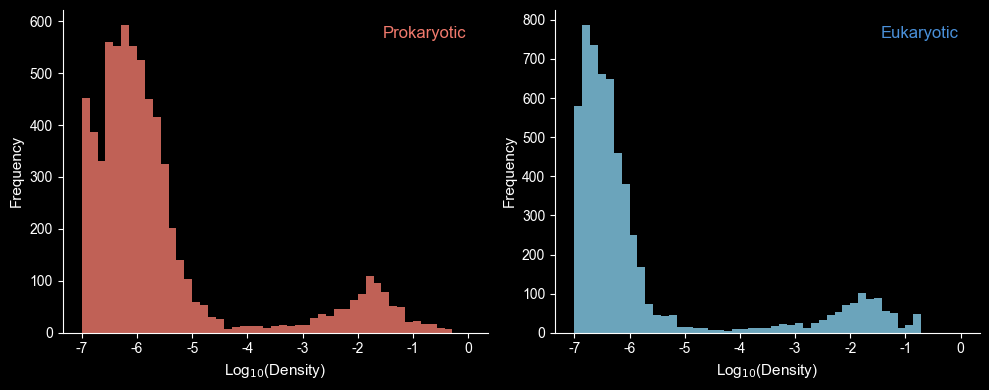

✓ SAE密度分布图(no_prefix)已保存: figures/fig2_sae_density.svg


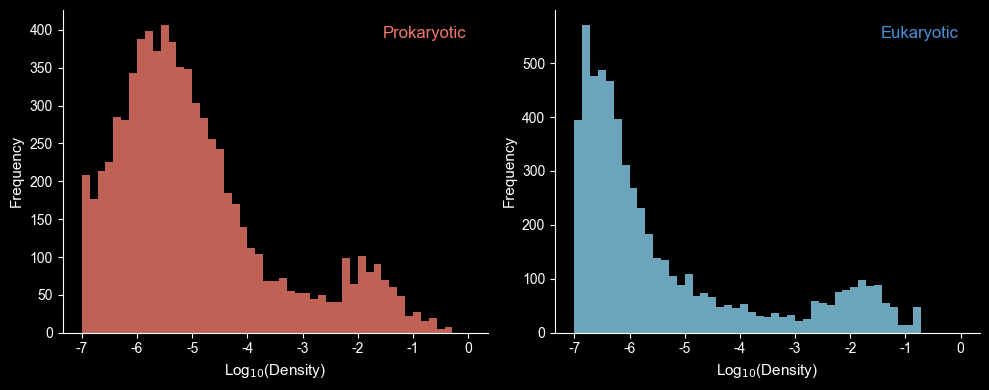

✓ SAE密度分布图(with_prefix)已保存: figures/fig2_sae_density_with_prefix.svg


In [5]:
# 2. SAE密度分布
density_no_prefix_file = os.path.join(INTERMEDIATE_DIR, 'sae_density_no_prefix.npz')
density_with_prefix_file = os.path.join(INTERMEDIATE_DIR, 'sae_density_with_prefix.npz')

print(f"检查文件: {density_no_prefix_file}")
print(f"文件存在: {os.path.exists(density_no_prefix_file)}")

def plot_density(data_no, data_with, output_path_no, output_path_with):
    """绘制no_prefix和with_prefix两张密度图"""
    # 使用固定bins (与原始脚本一致)
    bins = np.linspace(-7, 0, 50)
    
    # ============== no_prefix 版本 ==============
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    prok_density_no = data_no['prok_density']
    euk_density_no = data_no['euk_density']
    
    prok_valid = prok_density_no[prok_density_no > 0]
    euk_valid = euk_density_no[euk_density_no > 0]
    
    prok_log = np.log10(prok_valid)
    euk_log = np.log10(euk_valid)
    
    axes[0].hist(prok_log, bins=bins, color='#f27a6d', alpha=0.8, edgecolor='none')
    axes[0].set_xlabel('Log$_{10}$(Density)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].text(0.95, 0.95, 'Prokaryotic', transform=axes[0].transAxes, fontsize=12, fontweight='bold', color='#f27a6d', ha='right', va='top')
    
    axes[1].hist(euk_log, bins=bins, color='#87ceeb', alpha=0.8, edgecolor='none')
    axes[1].set_xlabel('Log$_{10}$(Density)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].text(0.95, 0.95, 'Eukaryotic', transform=axes[1].transAxes, fontsize=12, fontweight='bold', color='#4a90d9', ha='right', va='top')
    
    import seaborn as sns
    sns.despine()
    for ax in axes:
        ax.tick_params(direction='out')
    
    plt.tight_layout()
    plt.savefig(output_path_no, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f"✓ SAE密度分布图(no_prefix)已保存: {output_path_no}")
    
    # ============== with_prefix 版本 ==============
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    prok_density_with = data_with['prok_density']
    euk_density_with = data_with['euk_density']
    
    prok_valid = prok_density_with[prok_density_with > 0]
    euk_valid = euk_density_with[euk_density_with > 0]
    
    prok_log = np.log10(prok_valid)
    euk_log = np.log10(euk_valid)
    
    axes[0].hist(prok_log, bins=bins, color='#f27a6d', alpha=0.8, edgecolor='none')
    axes[0].set_xlabel('Log$_{10}$(Density)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].text(0.95, 0.95, 'Prokaryotic', transform=axes[0].transAxes, fontsize=12, fontweight='bold', color='#f27a6d', ha='right', va='top')
    
    axes[1].hist(euk_log, bins=bins, color='#87ceeb', alpha=0.8, edgecolor='none')
    axes[1].set_xlabel('Log$_{10}$(Density)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].text(0.95, 0.95, 'Eukaryotic', transform=axes[1].transAxes, fontsize=12, fontweight='bold', color='#4a90d9', ha='right', va='top')
    
    sns.despine()
    for ax in axes:
        ax.tick_params(direction='out')
    
    plt.tight_layout()
    plt.savefig(output_path_with, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f"✓ SAE密度分布图(with_prefix)已保存: {output_path_with}")

if os.path.exists(density_no_prefix_file) and os.path.exists(density_with_prefix_file):
    density_no = np.load(density_no_prefix_file, allow_pickle=True)
    density_with = np.load(density_with_prefix_file, allow_pickle=True)
    
    plot_density(
        density_no, density_with,
        os.path.join(OUTPUT_DIR, 'fig2_sae_density.svg'),
        os.path.join(OUTPUT_DIR, 'fig2_sae_density_with_prefix.svg')
    )
else:
    print("⚠ 未找到SAE密度数据文件")

## 3. SAE 平均激活 (SAE Mean Activation)

SAE特征数: 8192
Prokaryotic 平均激活范围: 0.000000 - 24.892174
Eukaryotic 平均激活范围: 0.000000 - 32.000072


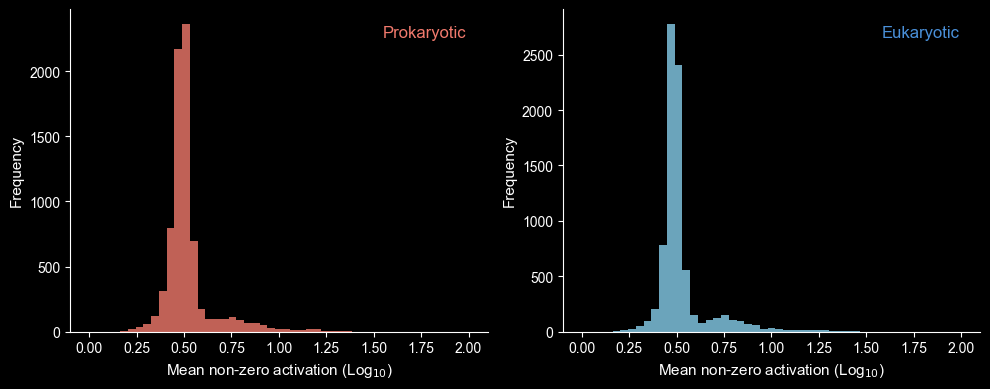

✓ SAE平均激活图(no_prefix)已保存: figures/fig3_sae_mean_activation.svg


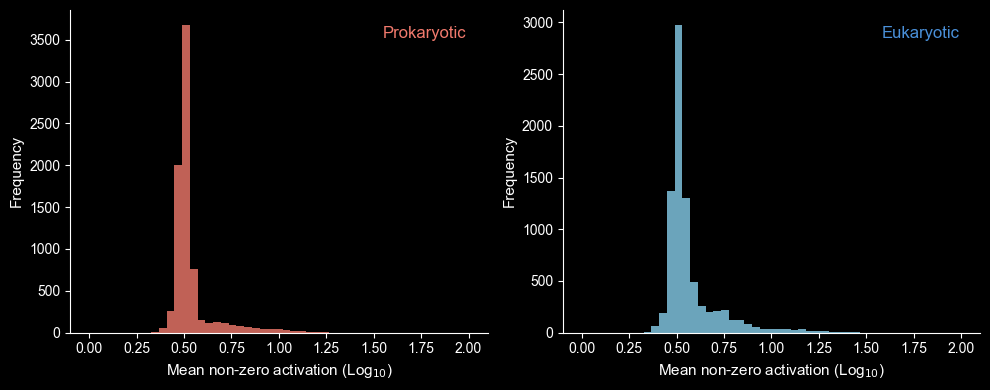

✓ SAE平均激活图(with_prefix)已保存: figures/fig3_sae_mean_activation_with_prefix.svg


In [6]:
# 3. SAE平均激活
mean_no_prefix_file = os.path.join(INTERMEDIATE_DIR, 'sae_mean_activation_no_prefix.npz')
mean_with_prefix_file = os.path.join(INTERMEDIATE_DIR, 'sae_mean_activation_with_prefix.npz')

def plot_mean_activation(data_no, data_with, output_path_no, output_path_with):
    """绘制no_prefix和with_prefix两张平均激活图"""
    prok_mean_no = data_no['prok_mean']
    euk_mean_no = data_no['euk_mean']
    
    print(f"SAE特征数: {len(prok_mean_no)}")
    print(f"Prokaryotic 平均激活范围: {prok_mean_no.min():.6f} - {prok_mean_no.max():.6f}")
    print(f"Eukaryotic 平均激活范围: {euk_mean_no.min():.6f} - {euk_mean_no.max():.6f}")
    
    # ============== no_prefix 版本 ==============
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    prok_valid = prok_mean_no[prok_mean_no > 0]
    euk_valid = euk_mean_no[euk_mean_no > 0]
    
    prok_log = np.log10(prok_valid)
    euk_log = np.log10(euk_valid)
    
    # 使用动态bins (与原始脚本一致)
    all_log = np.concatenate([prok_log, euk_log])
    min_val = np.floor(all_log.min())
    max_val = np.ceil(all_log.max())
    bins = np.linspace(min_val, max_val, 50)
    
    axes[0].hist(prok_log, bins=bins, color='#f27a6d', alpha=0.8, edgecolor='none')
    axes[0].set_xlabel('Mean non-zero activation (Log$_{10}$)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].text(0.95, 0.95, 'Prokaryotic', transform=axes[0].transAxes, fontsize=12, fontweight='bold', color='#f27a6d', ha='right', va='top')
    
    axes[1].hist(euk_log, bins=bins, color='#87ceeb', alpha=0.8, edgecolor='none')
    axes[1].set_xlabel('Mean non-zero activation (Log$_{10}$)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].text(0.95, 0.95, 'Eukaryotic', transform=axes[1].transAxes, fontsize=12, fontweight='bold', color='#4a90d9', ha='right', va='top')
    
    import seaborn as sns
    sns.despine()
    for ax in axes:
        ax.tick_params(direction='out')
    
    plt.tight_layout()
    plt.savefig(output_path_no, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f"✓ SAE平均激活图(no_prefix)已保存: {output_path_no}")
    
    # ============== with_prefix 版本 ==============
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    prok_mean_with = data_with['prok_mean']
    euk_mean_with = data_with['euk_mean']
    
    prok_valid = prok_mean_with[prok_mean_with > 0]
    euk_valid = euk_mean_with[euk_mean_with > 0]
    
    prok_log = np.log10(prok_valid)
    euk_log = np.log10(euk_valid)
    
    # 使用动态bins (与原始脚本一致)
    all_log = np.concatenate([prok_log, euk_log])
    min_val = np.floor(all_log.min())
    max_val = np.ceil(all_log.max())
    bins = np.linspace(min_val, max_val, 50)
    
    axes[0].hist(prok_log, bins=bins, color='#f27a6d', alpha=0.8, edgecolor='none')
    axes[0].set_xlabel('Mean non-zero activation (Log$_{10}$)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].text(0.95, 0.95, 'Prokaryotic', transform=axes[0].transAxes, fontsize=12, fontweight='bold', color='#f27a6d', ha='right', va='top')
    
    axes[1].hist(euk_log, bins=bins, color='#87ceeb', alpha=0.8, edgecolor='none')
    axes[1].set_xlabel('Mean non-zero activation (Log$_{10}$)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].text(0.95, 0.95, 'Eukaryotic', transform=axes[1].transAxes, fontsize=12, fontweight='bold', color='#4a90d9', ha='right', va='top')
    
    sns.despine()
    for ax in axes:
        ax.tick_params(direction='out')
    
    plt.tight_layout()
    plt.savefig(output_path_with, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f"✓ SAE平均激活图(with_prefix)已保存: {output_path_with}")

if os.path.exists(mean_no_prefix_file) and os.path.exists(mean_with_prefix_file):
    mean_no = np.load(mean_no_prefix_file, allow_pickle=True)
    mean_with = np.load(mean_with_prefix_file, allow_pickle=True)
    
    plot_mean_activation(
        mean_no, mean_with,
        os.path.join(OUTPUT_DIR, 'fig3_sae_mean_activation.svg'),
        os.path.join(OUTPUT_DIR, 'fig3_sae_mean_activation_with_prefix.svg')
    )
else:
    print("⚠ 未找到SAE平均激活数据文件")

## 4. UMAP 可视化

Embedding shape: (3584, 2)
Diff score shape: (3584,)

最显著的真核偏向特征 (蓝色):
  特征 #1021: diff_score = 0.3500
  特征 #732: diff_score = 0.2614
  特征 #3544: diff_score = 0.1831
  特征 #2317: diff_score = 0.1677
  特征 #1687: diff_score = 0.1585

最显著的原核偏向特征 (橙色):
  特征 #2869: diff_score = -0.3588
  特征 #3151: diff_score = -0.2691
  特征 #1203: diff_score = -0.2136
  特征 #1661: diff_score = -0.1891
  特征 #2754: diff_score = -0.1715


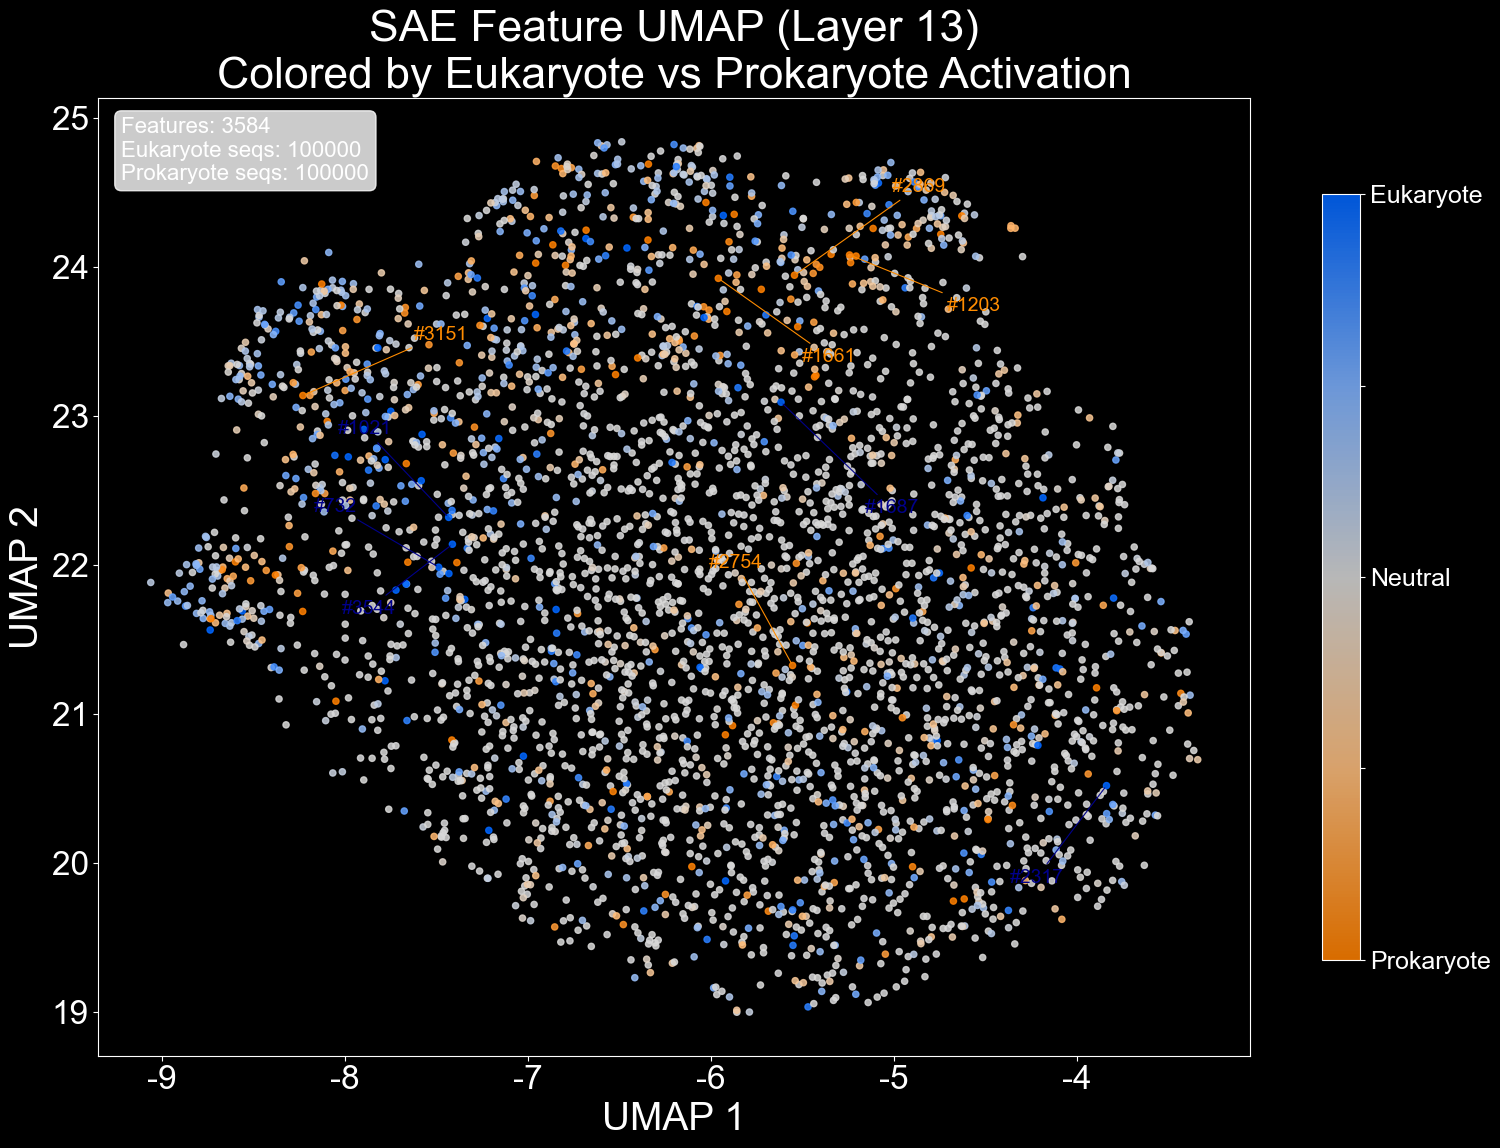

✓ UMAP图已保存


In [7]:
# 4. UMAP可视化
from matplotlib import rcParams

embedding_file = os.path.join(INTERMEDIATE_DIR, 'umap_embedding.npy')
diff_score_file = os.path.join(INTERMEDIATE_DIR, 'diff_score.npy')

if os.path.exists(embedding_file) and os.path.exists(diff_score_file):
    embedding = np.load(embedding_file, allow_pickle=True)
    diff_score = np.load(diff_score_file, allow_pickle=True)
    
    print(f"Embedding shape: {embedding.shape}")
    print(f"Diff score shape: {diff_score.shape}")
    
    LAYER = 13
    d_hid = len(diff_score)
    
    # 使用98百分位归一化
    percentile_98 = np.percentile(np.abs(diff_score), 98)
    if percentile_98 > 0:
        normalized_scores = np.clip(diff_score / percentile_98, -1, 1)
    else:
        normalized_scores = diff_score
    
    # 定义颜色：橙色和蓝色
    colors_custom = [
        (1.0, 0.5, 0.0),     # 橙色 (原核)
        (1.0, 0.75, 0.5),    # 浅橙
        (0.85, 0.85, 0.85),  # 灰
        (0.5, 0.7, 1.0),     # 浅蓝
        (0.0, 0.4, 1.0)      # 蓝色 (真核)
    ]
    cmap_custom = LinearSegmentedColormap.from_list('orange_blue', colors_custom)
    
    # 设置字体
    try:
        rcParams['font.family'] = 'Arial'
    except:
        rcParams['font.family'] = 'sans-serif'
    rcParams['font.size'] = 24
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # 绘制散点图 - 更大的点
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=normalized_scores,
        cmap=cmap_custom,
        s=20,
        alpha=0.85,
        vmin=-1,
        vmax=1
    )
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.set_ticklabels(['Prokaryote', '', 'Neutral', '', 'Eukaryote'])
    cbar.ax.tick_params(labelsize=18)
    
    ax.set_xlabel('UMAP 1', fontsize=28)
    ax.set_ylabel('UMAP 2', fontsize=28)
    ax.set_title(f'SAE Feature UMAP (Layer {LAYER})\nColored by Eukaryote vs Prokaryote Activation', fontsize=32)
    
    # 添加统计信息
    stats_text = f"Features: {d_hid}\nEukaryote seqs: 100000\nProkaryote seqs: 100000"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=16,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 标注最极端的10个特征（5个最蓝 + 5个最橙）
    top_euk_indices = np.argsort(diff_score)[-5:][::-1]  # 最大的5个（真核偏向）
    top_prok_indices = np.argsort(diff_score)[:5]  # 最小的5个（原核偏向）
    
    # 为每个标签定义不同的偏移位置（避免重叠）
    euk_offsets = [(-80, 60), (-90, 40), (-80, -50), (-70, -70), (60, -80)]
    prok_offsets = [(70, 60), (80, 40), (70, -40), (60, -60), (-60, 70)]
    
    print("\n最显著的真核偏向特征 (蓝色):")
    for i, idx in enumerate(top_euk_indices):
        print(f"  特征 #{idx}: diff_score = {diff_score[idx]:.4f}")
        ax.annotate(f'#{idx}',
                    xy=(embedding[idx, 0], embedding[idx, 1]),
                    xytext=euk_offsets[i], textcoords='offset points',
                    fontsize=14, color='darkblue',
                    arrowprops=dict(arrowstyle='-', color='darkblue', lw=0.8))
    
    print("\n最显著的原核偏向特征 (橙色):")
    for i, idx in enumerate(top_prok_indices):
        print(f"  特征 #{idx}: diff_score = {diff_score[idx]:.4f}")
        ax.annotate(f'#{idx}',
                    xy=(embedding[idx, 0], embedding[idx, 1]),
                    xytext=prok_offsets[i], textcoords='offset points',
                    fontsize=14, color='darkorange',
                    arrowprops=dict(arrowstyle='-', color='darkorange', lw=0.8))
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_umap.svg'), dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print("✓ UMAP图已保存")
else:
    print("⚠ 未找到UMAP数据文件")

## 5. circRNA 环形可视化

In [ ]:
# 5. circRNA 环形可视化
import matplotlib.patches as mpatches
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# 使用8192维的中间数据 (1400M模型 + sae_evo2_online_1400M)
circrabv_file = os.path.join(INTERMEDIATE_DIR, 'activations_RABV_G.npz')
circsars_file = os.path.join(INTERMEDIATE_DIR, 'activations_SARS_CoV2.npz')

if not (os.path.isfile(circrabv_file) and os.path.isfile(circsars_file)):
    print('⚠ 跳过 circRNA：缺少 activations_RABV_G.npz 或 activations_SARS_CoV2.npz')
else:
    rabv_data = np.load(circrabv_file, allow_pickle=True)
    sars_data = np.load(circsars_file, allow_pickle=True)

    print(f"RABV activations shape: {rabv_data['activations'].shape}")
    print(f"SARS activations shape: {sars_data['activations'].shape}")

    # ============== RABV-G ==============
    # 原始脚本手动指定: E1+E2=f/6073, IRES=f/7241, ORF=f/6772
    best_neurons_rabv = {'E1+E2': (6073, 0), 'IRES': (7241, 0), 'ORF': (6772, 0)}

    COLORS_RABV = {'E1+E2': '#50B9AE', 'Spacer': '#CCCCCC', 'IRES': '#73B9E7', 'ORF': '#FFA45B'}

    rabv_regions = [
        {'name': 'E1+E2', 'start': 0, 'end': 29, 'color': COLORS_RABV['E1+E2']},
        {'name': 'Spacer', 'start': 29, 'end': 36, 'color': COLORS_RABV['Spacer']},
        {'name': 'IRES', 'start': 36, 'end': 774, 'color': COLORS_RABV['IRES']},
        {'name': 'ORF', 'start': 774, 'end': 2348, 'color': COLORS_RABV['ORF']},
    ]

    def plot_circular_circRNA(activations, regions, total_len, best_neurons, output_path, title):
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
        angles = np.linspace(0, 2 * np.pi, total_len, endpoint=False)
        inner_radius = 0.55
        ring_width = 0.05

        for region in regions:
            start_angle = angles[region['start']] if region['start'] < total_len else 0
            end_angle = angles[min(region['end'] - 1, total_len - 1)]
            theta = np.linspace(start_angle, end_angle, 100)
            r_inner = np.full_like(theta, inner_radius)
            r_outer = np.full_like(theta, inner_radius + ring_width)
            ax.fill_between(theta, r_inner, r_outer, color=region['color'], alpha=0.9)

        outer_radius = inner_radius + ring_width + 0.02
        max_bar_height = 0.35
        bar_width = 2 * np.pi / total_len * 1.2
        leakage_inner_radius = inner_radius - 0.02
        leakage_max_height = 0.35

        max_act = max(np.max(activations[:, best_neurons[n][0]]) for n in best_neurons) or 1

        pos_to_region = [None] * total_len
        pos_to_color = ['#888888'] * total_len
        for region in regions:
            for i in range(region['start'], min(region['end'], total_len)):
                pos_to_region[i] = region['name']
                pos_to_color[i] = region['color']

        # 泄露部分
        for region in regions:
            name = region['name']
            if name not in best_neurons:
                continue
            neuron_idx, _ = best_neurons[name]
            start, end = region['start'], region['end']
            for i in range(total_len):
                if start <= i < end:
                    continue
                act_value = activations[i, neuron_idx]
                if act_value > 0:
                    height = (act_value / max_act) * leakage_max_height
                    ax.bar(angles[i], height, width=bar_width, bottom=leakage_inner_radius - height, color='#888888', alpha=0.4, edgecolor='none')

        # 区域内激活
        for i in range(total_len):
            name = pos_to_region[i]
            color = pos_to_color[i]
            if name and name in best_neurons:
                neuron_idx, _ = best_neurons[name]
                act_value = activations[i, neuron_idx]
                height = (act_value / max_act) * max_bar_height
            else:
                height = 0
            if height > 0:
                ax.bar(angles[i], height, width=bar_width, bottom=outer_radius, color=color, alpha=0.8, edgecolor='none')

        ax.set_ylim(0, 1.2)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.spines['polar'].set_visible(False)
        ax.grid(False)

        legend_order = ['IRES', 'ORF', 'E1+E2', 'Spacer']
        legend_elements = []
        for name in legend_order:
            region = next((r for r in regions if r['name'] == name), None)
            if region and name in best_neurons:
                neuron_id = best_neurons[name][0]
                legend_elements.append(mpatches.Patch(facecolor=region['color'], label=f"{name} (f/{neuron_id})"))
        ax.legend(handles=legend_elements, loc='center', fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.5), ncol=1)

        ax.set_title(title, fontsize=14, fontweight='bold', pad=-20)
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
        plt.show()
        print(f"✓ 图已保存: {output_path}")

    # 绘制RABV-G
    rabv_activations = rabv_data['activations']
    plot_circular_circRNA(rabv_activations, rabv_regions, len(rabv_activations), best_neurons_rabv, os.path.join(OUTPUT_DIR, 'fig5_circrna_rabv.svg'), 'circRNA RABV-G\nStructure-Specific Feature Activation')

    # ============== SARS-CoV-2 ==============
    # 原始脚本手动指定: IRES=f/7241, Foldon=f/7753, ORF=f/5979

    COLORS_SARS = {'Exon2': '#CCCCCC', 'IRES': '#73B9E7', 'ORF': '#FFA45B', 'GS_Linker': '#CCCCCC', 'Foldon': '#50B9AE', 'Exon1': '#CCCCCC'}

    sars_regions = [
        {'name': 'Exon2', 'start': 0, 'end': 51, 'color': COLORS_SARS['Exon2']},
        {'name': 'IRES', 'start': 51, 'end': 792, 'color': COLORS_SARS['IRES']},
        {'name': 'ORF', 'start': 792, 'end': 1554, 'color': COLORS_SARS['ORF']},
        {'name': 'GS_Linker', 'start': 1554, 'end': 1584, 'color': COLORS_SARS['GS_Linker']},
        {'name': 'Foldon', 'start': 1584, 'end': 1680, 'color': COLORS_SARS['Foldon']},
        {'name': 'Exon1', 'start': 1680, 'end': 1695, 'color': COLORS_SARS['Exon1']},
    ]

    # 手动指定SARS的最佳神经元 (与原始脚本一致)
    best_neurons_sars = {'IRES': (7241, 0), 'ORF': (5979, 0), 'Foldon': (7753, 0)}

    print("\nSARS-CoV-2 神经元 (原始脚本指定):")
    print(f"  IRES: f/7241")
    print(f"  ORF: f/5979")
    print(f"  Foldon: f/7753")

    def plot_circular_circRNA_sars(activations, regions, total_len, best_neurons, output_path, title):
        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
        angles = np.linspace(0, 2 * np.pi, total_len, endpoint=False)
        inner_radius = 0.55
        ring_width = 0.05

        for region in regions:
            start_angle = angles[region['start']] if region['start'] < total_len else 0
            end_angle = angles[min(region['end'] - 1, total_len - 1)]
            theta = np.linspace(start_angle, end_angle, 100)
            r_inner = np.full_like(theta, inner_radius)
            r_outer = np.full_like(theta, inner_radius + ring_width)
            ax.fill_between(theta, r_inner, r_outer, color=region['color'], alpha=0.9)

        outer_radius = inner_radius + ring_width + 0.02
        max_bar_height = 0.35
        bar_width = 2 * np.pi / total_len * 1.2
        leakage_inner_radius = inner_radius - 0.02
        leakage_max_height = 0.35

        max_act = max(np.max(activations[:, best_neurons[n][0]]) for n in best_neurons) or 1

        pos_to_region = [None] * total_len
        pos_to_color = ['#888888'] * total_len
        for region in regions:
            for i in range(region['start'], min(region['end'], total_len)):
                pos_to_region[i] = region['name']
                pos_to_color[i] = region['color']

        for region in regions:
            name = region['name']
            if name not in best_neurons:
                continue
            neuron_idx, _ = best_neurons[name]
            start, end = region['start'], region['end']
            for i in range(total_len):
                if start <= i < end:
                    continue
                act_value = activations[i, neuron_idx]
                if act_value > 0:
                    height = (act_value / max_act) * leakage_max_height
                    ax.bar(angles[i], height, width=bar_width, bottom=leakage_inner_radius - height, color='#888888', alpha=0.4, edgecolor='none')

        regions_to_show = {'IRES', 'ORF', 'Foldon'}
        for i in range(total_len):
            name = pos_to_region[i]
            color = pos_to_color[i]
            if name and name in best_neurons and name in regions_to_show:
                neuron_idx, _ = best_neurons[name]
                act_value = activations[i, neuron_idx]
                height = (act_value / max_act) * max_bar_height
            else:
                height = 0
            if height > 0:
                ax.bar(angles[i], height, width=bar_width, bottom=outer_radius, color=color, alpha=0.8, edgecolor='none')

        ax.set_ylim(0, 1.2)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.spines['polar'].set_visible(False)
        ax.grid(False)

        legend_order = ['IRES', 'ORF', 'Foldon']
        legend_elements = []
        for name in legend_order:
            region = next((r for r in regions if r['name'] == name), None)
            if region and name in best_neurons:
                neuron_id = best_neurons[name][0]
                legend_elements.append(mpatches.Patch(facecolor=region['color'], label=f"{name} (f/{neuron_id})"))
        ax.legend(handles=legend_elements, loc='center', fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.5), ncol=1)

        ax.set_title(title, fontsize=14, fontweight='bold', pad=-20)
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
        plt.show()
        print(f"✓ 图已保存: {output_path}")

    sars_activations = sars_data['activations']
    plot_circular_circRNA_sars(sars_activations, sars_regions, len(sars_activations), best_neurons_sars, os.path.join(OUTPUT_DIR, 'fig5_circrna_sars.svg'), 'circRNA SARS-CoV-2\nStructure-Specific Feature Activation')

    print("✓ circRNA环形图已保存")

## 6. mRNA Genome Browser

加载 HIV1_gp160: (2729, 8192)
加载 PR8_HA: (1859, 8192)
加载 RABV_G: (1733, 8192)
加载 VZV_gE: (2027, 8192)


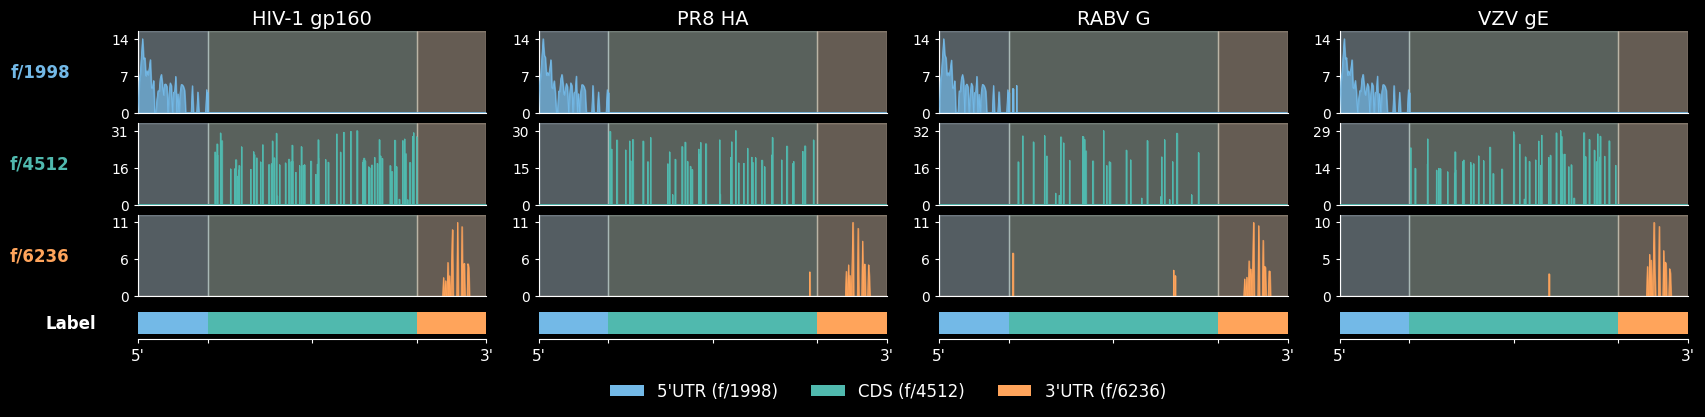

✓ 图已保存: figures/fig6_mrna.svg


In [9]:
# 6. mRNA Genome Browser - 复现原始combined_genome_browser_view.png
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Patch
import matplotlib as mpl

# mRNA配置 (与原始脚本一致)
MRNA_NAMES = ['HIV1_gp160', 'PR8_HA', 'RABV_G', 'VZV_gE']
MRNA_DISPLAY_NAMES = ['HIV-1 gp160', 'PR8 HA', 'RABV G', 'VZV gE']

# 神经元配置 (f/神经元序号 - 所有mRNA用相同神经元)
BEST_NEURONS = {
    'HIV1_gp160': {"5'UTR": 1998, "CDS": 4512, "3'UTR": 6236},
    'PR8_HA': {"5'UTR": 1998, "CDS": 4512, "3'UTR": 6236},
    'RABV_G': {"5'UTR": 1998, "CDS": 4512, "3'UTR": 6236},
    'VZV_gE': {"5'UTR": 1998, "CDS": 4512, "3'UTR": 6236},
}

# 颜色配置
COLORS = {
    "5'UTR": '#73B9E7',  # 蓝
    "CDS": '#50B9AE',    # 绿
    "3'UTR": '#FFA45B',  # 橙
}

# 背景色
BG_COLORS = {
    "5'UTR": '#D4E9F7',  # 浅蓝
    "CDS": '#E0F5E8',    # 浅绿
    "3'UTR": '#FFE8D0',  # 浅橙
}

def transform_coordinates(positions, utr5_end, cds_start, cds_end, utr3_start, seq_len):
    """坐标变换：压缩CDS区域，拉伸UTR区域"""
    utr5_len = utr5_end
    cds_len = cds_end - cds_start
    utr3_len = seq_len - utr3_start
    
    utr5_ratio = 0.2
    cds_ratio = 0.6
    utr3_ratio = 0.2
    
    new_positions = np.zeros_like(positions, dtype=float)
    
    for i, pos in enumerate(positions):
        if pos <= utr5_end:
            # 5'UTR区域
            if utr5_len > 0:
                new_positions[i] = (pos / utr5_len) * utr5_ratio
            else:
                new_positions[i] = 0
        elif pos <= cds_end:
            # CDS区域
            if cds_len > 0:
                new_positions[i] = utr5_ratio + ((pos - cds_start) / cds_len) * cds_ratio
            else:
                new_positions[i] = utr5_ratio
        else:
            # 3'UTR区域
            if utr3_len > 0:
                new_positions[i] = utr5_ratio + cds_ratio + ((pos - utr3_start) / utr3_len) * utr3_ratio
            else:
                new_positions[i] = utr5_ratio + cds_ratio
    
    return new_positions

def plot_genome_browser_view():
    """绘制基因组浏览器图"""
    # 加载所有数据
    all_data = {}
    for name in MRNA_NAMES:
        filepath = os.path.join(INTERMEDIATE_DIR, f'activations_{name}.npz')
        if os.path.exists(filepath):
            data = np.load(filepath, allow_pickle=True)
            all_data[name] = {
                'activations': data['activations'],
                'labels_utr5': data['labels_utr5'],
                'labels_cds': data['labels_cds'],
                'labels_utr3': data['labels_utr3'],
            }
            print(f"加载 {name}: {data['activations'].shape}")
    
    # 创建图形
    fig = plt.figure(figsize=(20, 4))
    
    # GridSpec: 4列，4行（3特征 + 标注）
    gs = gridspec.GridSpec(4, 4, height_ratios=[1, 1, 1, 0.4], 
                          width_ratios=[1, 1, 1, 1],
                          hspace=0.15, wspace=0.15,
                          top=0.88)
    
    tracks = [("5'UTR", 'labels_utr5'), ("CDS", 'labels_cds'), ("3'UTR", 'labels_utr3')]
    
    for col, (mrna_name, display_name) in enumerate(zip(MRNA_NAMES, MRNA_DISPLAY_NAMES)):
        if mrna_name not in all_data:
            continue
            
        data = all_data[mrna_name]
        activations = data['activations']
        seq_len = activations.shape[0]
        positions = np.arange(seq_len)
        
        # 获取结构边界
        utr5_mask = data['labels_utr5']
        cds_mask = data['labels_cds']
        utr3_mask = data['labels_utr3']
        
        utr5_end = np.where(utr5_mask > 0.5)[0][-1] if np.any(utr5_mask > 0.5) else 0
        cds_start = np.where(cds_mask > 0.5)[0][0] if np.any(cds_mask > 0.5) else 0
        cds_end = np.where(cds_mask > 0.5)[0][-1] if np.any(cds_mask > 0.5) else seq_len
        utr3_start = np.where(utr3_mask > 0.5)[0][0] if np.any(utr3_mask > 0.5) else seq_len
        
        # 坐标变换
        new_positions = transform_coordinates(positions, utr5_end, cds_start, cds_end, utr3_start, seq_len)
        
        # 变换后的边界
        new_utr5_end = 0.2
        new_cds_start = 0.2
        new_cds_end = 0.8
        new_utr3_start = 0.8
        
        for row, (track_name, label_key) in enumerate(tracks):
            ax = fig.add_subplot(gs[row, col])
            
            neuron_idx = BEST_NEURONS[mrna_name][track_name]
            feature_activation = activations[:, neuron_idx]
            
            # 添加三个区域的背景色
            ax.axvspan(0, new_utr5_end, alpha=0.4, color=BG_COLORS["5'UTR"], zorder=0)
            ax.axvspan(new_cds_start, new_cds_end, alpha=0.4, color=BG_COLORS["CDS"], zorder=0)
            ax.axvspan(new_utr3_start, 1.0, alpha=0.4, color=BG_COLORS["3'UTR"], zorder=0)
            
            # 绘制填充面积图
            ax.fill_between(new_positions, feature_activation, alpha=0.7, 
                           color=COLORS[track_name], zorder=2)
            ax.plot(new_positions, feature_activation, color=COLORS[track_name], 
                   linewidth=0.6, zorder=3)
            
            ax.set_xlim(0, 1)
            ax.set_ylim(0, max(feature_activation) * 1.1 if max(feature_activation) > 0 else 1)
            
            # 左侧标签 - 使用f/格式
            if col == 0:
                ax.set_ylabel(f"f/{neuron_idx}", fontsize=12, fontweight='bold',
                             color=COLORS[track_name], rotation=0, ha='right', va='center',
                             labelpad=30)
            
            # 顶部标题
            if row == 0:
                ax.set_title(f'{display_name}', fontsize=14, pad=5)
            
            # x轴刻度
            ax.tick_params(axis='x', labelbottom=False, length=0)
            
            # y轴刻度
            max_val = max(feature_activation) if max(feature_activation) > 0 else 1
            ax.set_yticks([0, max_val * 0.5, max_val])
            ax.set_yticklabels(['0', f'{max_val*0.5:.0f}', f'{max_val:.0f}'], fontsize=10)
            
            # 美化
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='y', labelsize=10, length=3)
        
        # 标注轨道（底部）
        ax_annot = fig.add_subplot(gs[3, col])
        
        bar_height = 0.7
        y_center = 0.5
        
        rect_utr5 = Rectangle((0, y_center - bar_height/2), new_utr5_end, bar_height,
                              facecolor=COLORS["5'UTR"], edgecolor='none', linewidth=0)
        ax_annot.add_patch(rect_utr5)
        
        rect_cds = Rectangle((new_cds_start, y_center - bar_height/2), 
                             new_cds_end - new_cds_start, bar_height,
                             facecolor=COLORS["CDS"], edgecolor='none', linewidth=0)
        ax_annot.add_patch(rect_cds)
        
        rect_utr3 = Rectangle((new_utr3_start, y_center - bar_height/2), 
                              1.0 - new_utr3_start, bar_height,
                              facecolor=COLORS["3'UTR"], edgecolor='none', linewidth=0)
        ax_annot.add_patch(rect_utr3)
        
        ax_annot.set_xlim(0, 1)
        ax_annot.set_ylim(0, 1)
        ax_annot.set_yticks([])
        ax_annot.set_xticks([0, 0.2, 0.5, 0.8, 1.0])
        ax_annot.set_xticklabels(["5'", '', '', '', "3'"], fontsize=11)
        ax_annot.spines['top'].set_visible(False)
        ax_annot.spines['right'].set_visible(False)
        ax_annot.spines['left'].set_visible(False)
        ax_annot.tick_params(axis='x', length=3)
        
        # 左侧标签
        if col == 0:
            ax_annot.set_ylabel('Label', fontsize=12, fontweight='bold', 
                               rotation=0, ha='right', va='center', labelpad=30)
    
    # 图例
    legend_elements = [
        Patch(facecolor=COLORS["5'UTR"], edgecolor='none', label="5'UTR (f/1998)"),
        Patch(facecolor=COLORS["CDS"], edgecolor='none', label="CDS (f/4512)"),
        Patch(facecolor=COLORS["3'UTR"], edgecolor='none', label="3'UTR (f/6236)"),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
              fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.08))
    
    # 保存
    output_path = os.path.join(OUTPUT_DIR, 'fig6_mrna.svg')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f"✓ 图已保存: {output_path}")

# 绘制基因组浏览器图
plot_genome_browser_view()

## 7. 基因本质性预测 (Zero-shot Essentiality)

In [ ]:
# 7. 基因本质性预测 (Zero-shot Essentiality)
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

try:
    import reproduce_paths as RP
except ModuleNotFoundError:
    from notebooks.interpretability_analysis import reproduce_paths as RP

if RP.try_register_arial():
    plt.rcParams["font.family"] = "Arial"
else:
    plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

_INTER = RP.intermediate_dir()
_OUT = RP.figures_dir()
_OUT.mkdir(parents=True, exist_ok=True)

bacteria_path = _INTER / "bacteria_full_comparison_results.json"
euk_path = _INTER / "eukaryote_gc_baseline_results.json"
if not bacteria_path.is_file() or not euk_path.is_file():
    print("⚠ 缺少 essentiality JSON，请运行 interpretability/zeroshot_essentiality 下 plot_*.py 生成后拷贝到 intermediate_data/")
else:
    bacteria_data = json.load(open(bacteria_path))
    eukaryote_data = json.load(open(euk_path))

    orange_color = (255/255, 164/255, 91/255)
    blue_color = (115/255, 185/255, 231/255)
    gray_color = (207/255, 208/255, 209/255)

    def _mean_std(summary, key):
        block = summary.get(key) or {}
        return block.get("mean", float("nan")), block.get("std", 0.0)

    bacteria_summary = bacteria_data["summary"]
    bacteria_results = bacteria_data["per_species"]
    bacteria_plan = [
        ("Position\nBaseline", "position", "position_baseline", gray_color),
        ("Evo2 1B", "evo2_1b", "evo2_1b", blue_color),
        ("Evo2 7B", "evo2_7b", "evo2_7b", blue_color),
        ("Evo2 40B", "evo2_40b", "evo2_40b", blue_color),
        ("EVA 21M", "rnagen_30m", "rnagen_30m", orange_color),
        ("EVA 1.4B", "rnagen_1400m", "rnagen_1400m", orange_color),
    ]
    model_data_bacteria = []
    for disp, pkey, skey, col in bacteria_plan:
        if skey not in bacteria_summary:
            continue
        m, _ = _mean_std(bacteria_summary, skey)
        model_data_bacteria.append((disp, pkey, m, col))
    if not model_data_bacteria:
        print("⚠ bacteria JSON 无可用 summary 字段")
    else:
        print(f"细菌图: {len(model_data_bacteria)} 行（若 JSON 含 evo2_40b 则为 6 行）")
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_facecolor("white")
        fig.patch.set_facecolor("white")
        y_positions = np.arange(len(model_data_bacteria))
        for i, (name, key, mean, color) in enumerate(model_data_bacteria):
            ax.barh(i, mean, height=0.75, color=color, alpha=0.8, edgecolor="black", linewidth=1.2)
        np.random.seed(42)
        for i, (name, key, mean, color) in enumerate(model_data_bacteria):
            values = [r[key] for r in bacteria_results if key in r and r[key] is not None]
            jitter = np.random.uniform(-0.2, 0.2, len(values))
            ax.scatter(values, i + jitter, c="black", alpha=0.4, s=15, zorder=5)
        ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)
        ax.set_yticks(y_positions)
        ax.set_yticklabels([m[0] for m in model_data_bacteria], fontsize=24)
        ax.set_xlabel("AUROC", fontsize=26)
        ax.set_title("Zero-shot Gene Essentiality Prediction", fontsize=26)
        ax.tick_params(axis="x", labelsize=20)
        ax.set_xlim(0.4, 0.85)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("black")
        ax.grid(axis="x", alpha=0.2, linestyle="-", linewidth=0.5)
        ax.set_axisbelow(True)
        plt.tight_layout()
        plt.savefig(_OUT / "fig7_essentiality_bacteria.svg", dpi=300, bbox_inches="tight", transparent=True)
        plt.show()
        print("✓ 细菌基因本质性预测图已保存")

    eukaryote_summary = eukaryote_data["summary"]
    eukaryote_results = eukaryote_data["per_species"]
    euk_plan = [
        ("GC Content\nBaseline", "gc_baseline", "gc_baseline", gray_color),
        ("Evo2 1B", "evo2_1b", "evo2_1b", blue_color),
        ("Evo2 7B", "evo2_7b", "evo2_7b", blue_color),
        ("Evo2 40B", "evo2_40b", "evo2_40b", blue_color),
        ("EVA 21M", "rnagen_30m", "rnagen_30m", orange_color),
        ("EVA 1.4B", "rnagen_1400m", "rnagen_1400m", orange_color),
    ]
    model_data_euk = []
    for disp, pkey, skey, col in euk_plan:
        if skey not in eukaryote_summary:
            continue
        m, _ = _mean_std(eukaryote_summary, skey)
        model_data_euk.append((disp, pkey, m, col))
    if model_data_euk:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_facecolor("white")
        fig.patch.set_facecolor("white")
        y_positions = np.arange(len(model_data_euk))
        for i, (name, key, mean, color) in enumerate(model_data_euk):
            ax.barh(i, mean, height=0.75, color=color, alpha=0.8, edgecolor="black", linewidth=1.2)
        np.random.seed(42)
        for i, (name, key, mean, color) in enumerate(model_data_euk):
            values = [r[key] for r in eukaryote_results if key in r and not (isinstance(r[key], float) and np.isnan(r[key]))]
            jitter = np.random.uniform(-0.2, 0.2, len(values))
            ax.scatter(values, i + jitter, c="black", alpha=0.4, s=15, zorder=5)
        ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)
        ax.set_yticks(y_positions)
        ax.set_yticklabels([m[0] for m in model_data_euk], fontsize=24)
        ax.set_xlabel("AUROC", fontsize=26)
        ax.set_title("Zero-shot Gene Essentiality Prediction", fontsize=26)
        ax.tick_params(axis="x", labelsize=20)
        ax.set_xlim(0.4, 0.7)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("black")
        ax.grid(axis="x", alpha=0.2, linestyle="-", linewidth=0.5)
        ax.set_axisbelow(True)
        plt.tight_layout()
        plt.savefig(_OUT / "fig7_essentiality_eukaryote.svg", dpi=300, bbox_inches="tight", transparent=True)
        plt.show()
        print("✓ 真核基因本质性预测图已保存")
